In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. LOAD DATASETS

# Load Powell inflow + elevation time series
df = pd.read_excel("Results_Paleo.xlsx")
#df = pd.read_excel("Results_CMIP5.xlsx")
# Load Powell elevation–area–capacity table
elev_table = pd.read_csv("elevPowell.csv")



# 2. CLEAN + STANDARDIZE ELEVATION–STORAGE TABLE


elev_table = elev_table.rename(columns={
    "Elevation_ft_NAVD88": "elevation_ft",
    "Capacity_acrefeet": "storage_acft",
    "Area_acres": "area_acres"
})

elev_table = elev_table.sort_values("elevation_ft")



# 3. INTERPOLATION FUNCTIONS


def elev_to_storage(elev):
    """Convert elevation (ft) → storage (acre‑feet)."""
    return np.interp(
        elev,
        elev_table["elevation_ft"],
        elev_table["storage_acft"]
    )

def storage_to_elev(storage):
    """Convert storage (acre‑feet) → elevation (ft)."""
    return np.interp(
        storage,
        elev_table["storage_acft"],
        elev_table["elevation_ft"]
    )

def elev_to_area(elev):
    """Convert elevation (ft) → surface area (acres)."""
    return np.interp(
        elev,
        elev_table["elevation_ft"],
        elev_table["area_acres"]
    )



# 4. CLEAN THE POWELL INFLOW DATASET


df = df.rename(columns={"Unnamed: 0": "date"})
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["Powell.Inflow"] = pd.to_numeric(df["Powell.Inflow"], errors="coerce")
df["Powell.Outflow"] = pd.to_numeric(df["Powell.Outflow"], errors="coerce")
df["Powell.EffectiveElevation"] = pd.to_numeric(df["Powell.EffectiveElevation"], errors="coerce")
df["Powell.EffectiveStorage"] = pd.to_numeric(df["Powell.EffectiveStorage"], errors="coerce")

#df = df.iloc[:-24]

#df = df[(df["date"].dt.year >= 2024) & (df["date"].dt.year <= 2040)].reset_index(drop=True)

# ── EVAPORATION SETUP ──────────────────────────────────────────────────────────
# Mean monthly net evaporation depth for Lake Powell (ft/month)
# Source: Clayton, R. “Reclamation Evaporation Methodology for Lake Powell.” Unpublished Report. U.S. 478 Bureau of Reclamation, Upper Colorado Region, Salt Lake City, UT. (2008): 479.
# These are approximate long-term averages
monthly_net_evap_ft = {
    1:  0.164,   # 50 mm
    2:  0.164,   # 50 mm
    3:  0.262,   # 80 mm
    4:  0.377,   # 115 mm
    5:  0.427,   # 130 mm
    6:  0.623,   # 190 mm
    7:  0.755,   # 230 mm
    8:  0.755,   # 230 mm
    9:  0.722,   # 220 mm
    10: 0.535,   # 163 mm
    11: 0.492,   # 150 mm
    12: 0.295,   # 90 mm
}
def monthly_evap_acft(elev, month):
    """
    Compute evaporative loss (acre-feet) for a given month.
    Uses the surface area at the given elevation and the net evaporation depth.
    """
    area = elev_to_area(elev)                      # acres
    depth = monthly_net_evap_ft.get(month, 0.15)   # ft/month
    return area * depth                             # acre-feet
# 5. ADD DERIVED INITIAL‑CONDITION FIELDS


df["storage_from_elev"] = elev_to_storage(df["Powell.EffectiveElevation"])
df["area_from_elev"] = elev_to_area(df["Powell.EffectiveElevation"])



# EXTRACT THE ANALYSIS DATASET


analysis_df = df[[
    "date",
    "Powell.Inflow",
    "Powell.Outflow",
    "Powell.EffectiveElevation",
    "Powell.EffectiveStorage"
]].copy()






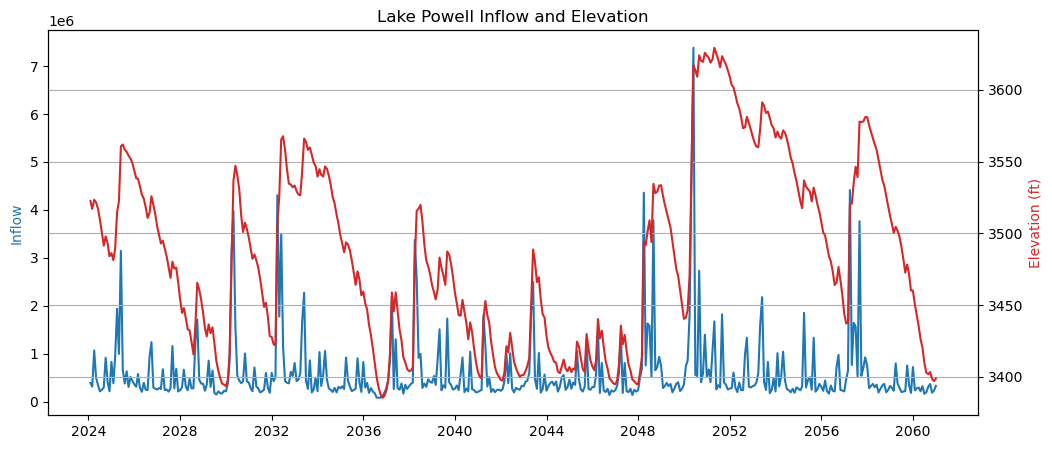

In [113]:
# QUICK VISUAL CHECK

fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(df["date"], df["Powell.Inflow"], color="tab:blue")
ax1.set_ylabel("Inflow", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(df["date"], df["Powell.EffectiveElevation"], color="tab:red")
ax2.set_ylabel("Elevation (ft)", color="tab:red")

plt.title("Lake Powell Inflow and Elevation")
plt.grid(True)
plt.show()

In [114]:
# 8. MASS BALANCE WITH BASE RELEASE + 3525/3530 RULE
annual_release_acft = 8.23e6
base_monthly_release = annual_release_acft / 12.0

df["Scenario1.Outflow"] = np.nan
scenario_storage = np.zeros(len(df))
scenario_elev = np.zeros(len(df))

scenario_elev[0] = 3525.0
scenario_storage[0] = elev_to_storage(3525.0)

last_year_reduced = False
reduced_this_year = False

for t in range(1, len(df)):
    prev_storage = scenario_storage[t-1]
    prev_elev    = scenario_elev[t-1]
    Qin          = df.loc[t, "Powell.Inflow"]
    month        = df.loc[t, "date"].month

    if prev_elev < 3525:
        Qout = 0.95 * Qin
        reduced_this_year = True
    elif last_year_reduced and prev_elev < 3535:
        Qout = 0.95 * Qin
        reduced_this_year = True
    else:
        Qout = base_monthly_release
        reduced_this_year = False

    Qout = min(Qout, base_monthly_release)
    Qevap = monthly_evap_acft(prev_elev, month)

    df.loc[t, "Scenario1.Outflow"] = Qout
    scenario_storage[t] = prev_storage + Qin - Qout - Qevap
    scenario_elev[t]    = storage_to_elev(scenario_storage[t])

    if month == 12:
        last_year_reduced = reduced_this_year

df["Scenario1.Evap"] = [
    monthly_evap_acft(scenario_elev[t], df.loc[t, "date"].month)
    for t in range(len(df))
]

df["Scenario.Storage"]   = scenario_storage
df["Scenario.Elevation"] = scenario_elev

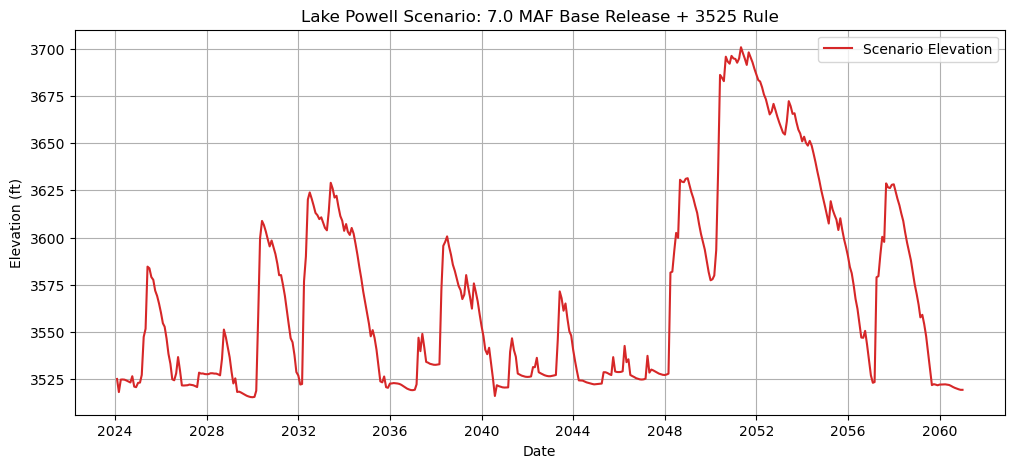

In [115]:
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(df["date"], df["Scenario.Elevation"], label="Scenario Elevation", color="tab:red")
#ax.plot(df["date"], df["Powell.EffectiveElevation"], label="Observed Elevation", color="tab:blue")

ax.set_ylabel("Elevation (ft)")
ax.set_xlabel("Date")
ax.grid(True)
ax.legend()
plt.title("Lake Powell Scenario: 7.0 MAF Base Release + 3525 Rule")
plt.show()


In [116]:
# SCENARIO 2: RELEASE CAN ONLY CHANGE EVERY 6 MONTHS

df["Scenario2.Outflow"] = np.nan

scenario2_storage = np.zeros(len(df))
scenario2_elev = np.zeros(len(df))

# Start at elevation 3525 ft
scenario2_elev[0] = 3525.0
scenario2_storage[0] = elev_to_storage(3525.0)

# Memory variable for reduced-release mode
last_year_reduced = False

# Initialize release at t=0 using correct inflow
Qin0 = df.loc[0, "Powell.Inflow"]
if scenario2_elev[0] < 3525:
    current_release = 0.95 * Qin0
    reduced_this_year = True
else:
    current_release = base_monthly_release
    reduced_this_year = False

for t in range(1, len(df)):

    prev_storage = scenario2_storage[t-1]
    prev_elev = scenario2_elev[t-1]

    # use current month's inflow
    Qin = df.loc[t, "Powell.Inflow"]

    # Determine if we are at the start of a 6-month block
    month = df.loc[t, "date"].month
    is_block_start = (month == 1) or (month == 7)

    if is_block_start:

        # APPLY RULES ONLY AT BLOCK START
        if prev_elev < 3525:
            current_release = 0.95 * Qin
            reduced_this_year = True

        elif last_year_reduced and prev_elev < 3535:
            current_release = 0.95 * Qin
            reduced_this_year = True

        else:
            current_release = base_monthly_release
            reduced_this_year = False

    # Use the locked-in release for this month
    Qout = current_release
    Qevap = monthly_evap_acft(prev_elev, month)

    # write outflow to the correct row
    df.loc[t, "Scenario2.Outflow"] = Qout

    # Mass balance
    scenario2_storage[t] = prev_storage + Qin - Qout - Qevap

    # Convert storage → elevation
    scenario2_elev[t] = storage_to_elev(scenario2_storage[t])

    # Update memory at year boundaries
    if month == 12:
        last_year_reduced = reduced_this_year

df["Scenario2.Storage"] = scenario2_storage
df["Scenario2.Elevation"] = scenario2_elev


In [117]:
# # SCENARIO 3: RELEASE CAN ONLY CHANGE EVERY YEAR

# df["Scenario3.Outflow"] = np.nan

# scenario3_storage = np.zeros(len(df))
# scenario3_elev = np.zeros(len(df))

# # Start at elevation 3525 ft
# scenario3_elev[0] = 3525.0
# scenario3_storage[0] = elev_to_storage(3525.0)

# # Memory variable for reduced-release mode
# last_year_reduced = False

# # Initialize release at t=0 using correct inflow
# Qin0 = df.loc[0, "Powell.Inflow"]
# if scenario3_elev[0] < 3525:
#     current_release = 0.95 * Qin0
#     reduced_this_year = True
# else:
#     current_release = base_monthly_release
#     reduced_this_year = False

# for t in range(1, len(df)):

#     prev_storage = scenario3_storage[t-1]
#     prev_elev = scenario3_elev[t-1]

#     # use current month's inflow
#     Qin = df.loc[t, "Powell.Inflow"]

#     # Determine if we are at the start of a 12-month block
#     month = df.loc[t, "date"].month
#     is_block_start = (month == 1) or (month == 13)

#     if is_block_start:

#         # APPLY RULES ONLY AT BLOCK START
#         if prev_elev < 3525:
#             current_release = 0.95 * Qin
#             reduced_this_year = True

#         elif last_year_reduced and prev_elev < 3535:
#             current_release = 0.95 * Qin
#             reduced_this_year = True

#         else:
#             current_release = base_monthly_release
#             reduced_this_year = False

#     # Use the locked-in release for this month
#     Qout = current_release
#     Qevap = monthly_evap_acft(prev_elev, month)

#     # write outflow to the correct row
#     df.loc[t, "Scenario3.Outflow"] = Qout

#     # Mass balance
#     scenario3_storage[t] = prev_storage + Qin - Qout - Qevap

#     # Convert storage → elevation
#     scenario3_elev[t] = storage_to_elev(scenario3_storage[t])

#     # Update memory at year boundaries
#     if month == 12:
#         last_year_reduced = reduced_this_year

# df["Scenario3.Storage"] = scenario3_storage
# df["Scenario3.Elevation"] = scenario3_elev


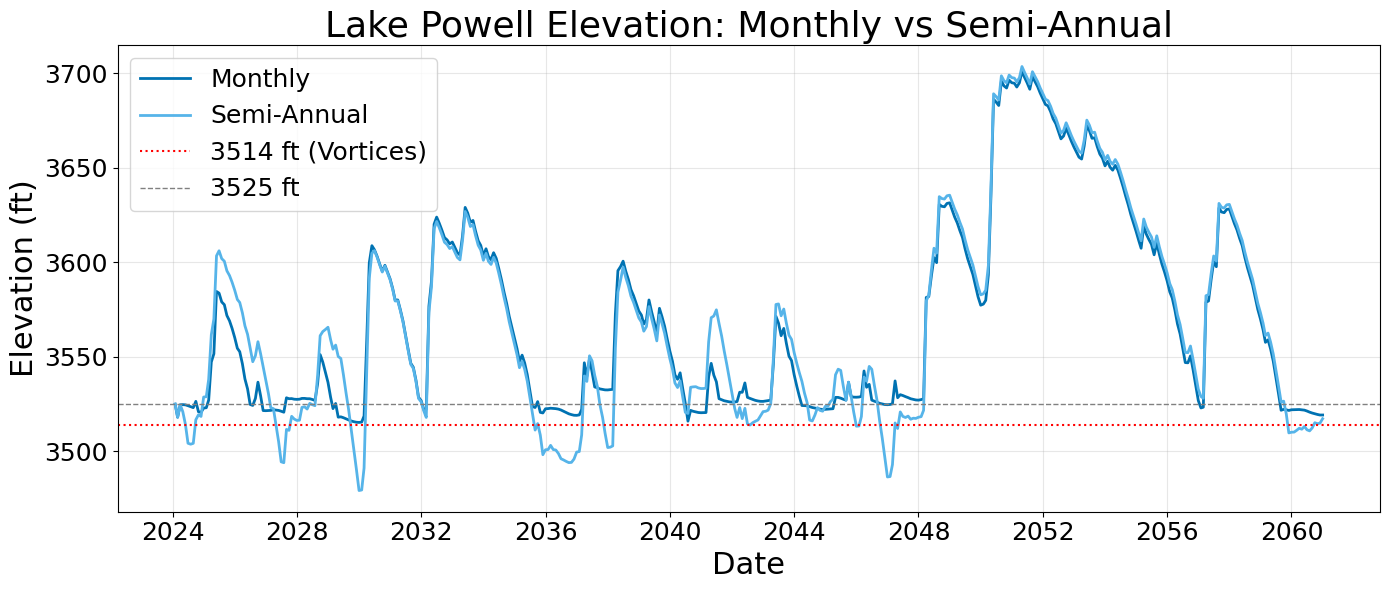

In [141]:
plt.figure(figsize=(14,6))
plt.plot(df["date"], df["Scenario.Elevation"],
         label="Monthly",
         color="#0072B2", linewidth=2.0)

plt.plot(df["date"], df["Scenario2.Elevation"],
          label="Semi-Annual",
          color="#56B4E9", linewidth=2.0)

# plt.plot(df["date"], df["Powell.EffectiveElevation"],
#          label = "No New Rule",
#          color="#000000")
# plt.plot(df["date"], df["Scenario3.Elevation"],
#          label="Annual",
#          color="#92C5DE", linewidth=2.0)
plt.axhline(3514, color="red", linestyle=":", linewidth=1.5, label="3514 ft (Vortices)")
plt.axhline(3525, color="gray", linestyle="--", linewidth=1.0, label="3525 ft")
#plt.axhline(3490, color="gray", linestyle=":", linewidth=2.0, label="3490 ft")
plt.title("Lake Powell Elevation: Monthly vs Semi-Annual", fontsize=26)
plt.xlabel("Date", fontsize=22)
plt.ylabel("Elevation (ft)", fontsize=22)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

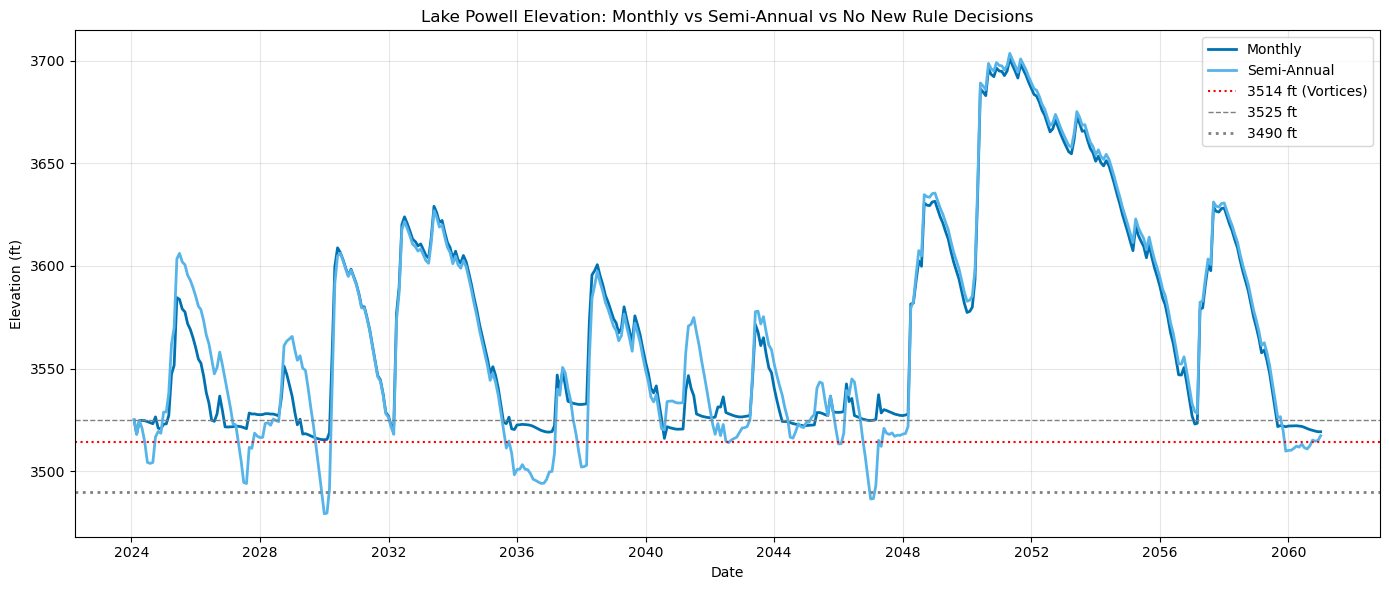

In [137]:
plt.figure(figsize=(14,6))

plt.plot(df["date"], df["Scenario.Elevation"],
         label="Monthly",
         color="#0072B2", linewidth=2.0)



plt.plot(df["date"], df["Scenario2.Elevation"],
          label="Semi-Annual",
          color="#56B4E9", linewidth=2.0)


plt.plot(df["date"], df["Powell.EffectiveElevation"],
         label = "No New Rule",
         color="#000000")

# plt.plot(df["date"], df["Scenario3.Elevation"],
#          label="Annual",
#          color="#92C5DE", linewidth=2.0)

plt.axhline(3514, color="red", linestyle=":", linewidth=1.5, label="3514 ft (Vortices)")
plt.axhline(3525, color="gray", linestyle="--", linewidth=1.0, label="3525 ft")
plt.axhline(3490, color="gray", linestyle=":", linewidth=2.0, label="3490 ft")

plt.title("Lake Powell Elevation: Monthly vs Semi-Annual vs No New Rule Decisions")
plt.xlabel("Date")
plt.ylabel("Elevation (ft)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [124]:

scenario_cols = [c for c in df.columns if c.lower().startswith("scenario") and "outflow" in c.lower()]
scenario_cols

df["year"] = df["date"].dt.year
annual = df.groupby("year")[scenario_cols].sum()
annual



,Scenario1.Outflow,Scenario2.Outflow,Powell.Outflow
year,,,
2024,5.150787e+06,4.838375e+06,7.900000e+06
2025,7.906835e+06,6.291011e+06,7.085076e+06
2026,7.323473e+06,8.230000e+06,7.480000e+06
2027,4.101953e+06,5.682270e+06,7.000000e+06
2028,5.841325e+06,3.277208e+06,7.000000e+06
2029,4.611676e+06,8.230000e+06,5.243763e+06
2030,7.898946e+06,6.243679e+06,9.496758e+06
2031,8.230000e+06,8.230000e+06,6.897919e+06
2032,8.026291e+06,8.230000e+06,9.602081e+06


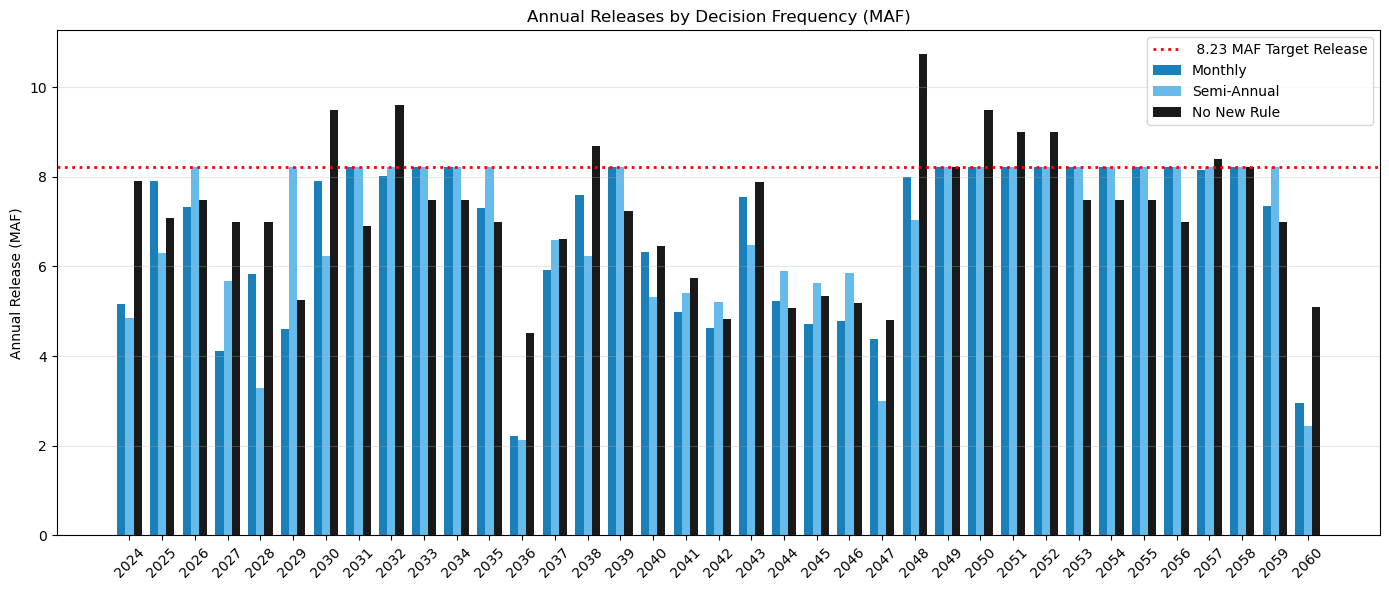

In [125]:

# Colorblind-friendly blues (Okabe–Ito palette)
colors = {
    "Scenario1.Outflow": "#0072B2",  # blue
    "Scenario2.Outflow": "#56B4E9",  # sky blue
    "Powell.Outflow": "#000000",  # black
}

# Friendly labels for legend
labels = {
    "Scenario1.Outflow": "Monthly",
    "Scenario2.Outflow": "Semi-Annual",
    "Powell.Outflow": "No New Rule", 

}

# Convert to MAF
annual_maf = annual / 1_000_000

# Setup for grouped bars
years = annual_maf.index
n_years = len(years)
n_scenarios = len(annual_maf.columns)

bar_width = 0.25
x = np.arange(n_years)

plt.figure(figsize=(14,6))

for i, col in enumerate(annual_maf.columns):
    plt.bar(
        x + i * bar_width,
        annual_maf[col],
        width=bar_width,
        label=labels[col],      # ← updated label
        color=colors[col],
        alpha=0.9
    )
plt.axhline(8.23, color="red", linestyle=":", linewidth=2.0, label= " 8.23 MAF Target Release")

plt.xticks(x + bar_width, years, rotation=45)
plt.ylabel("Annual Release (MAF)")
plt.title("Annual Releases by Decision Frequency (MAF)")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


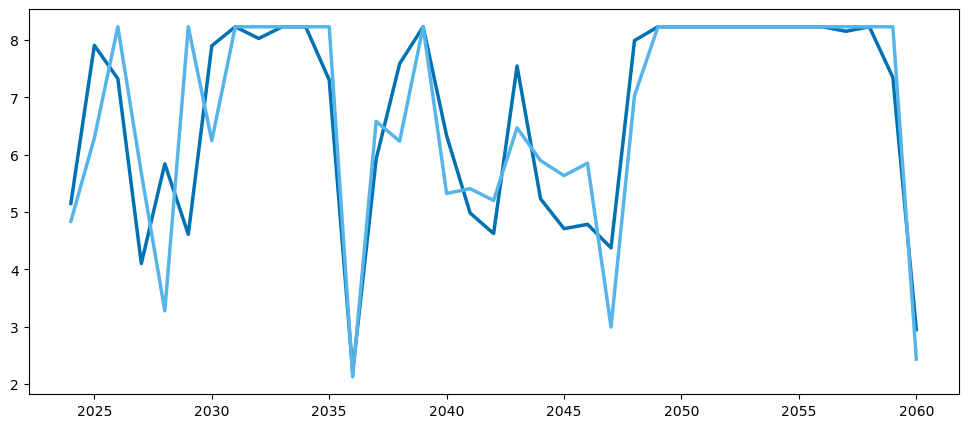

In [121]:
plt.figure(figsize=(12,5))

for col in annual_maf.columns:
    plt.plot(
        annual_maf.index,
        annual_maf[col],
        label=col.replace(".Outflow", ""),
        color=colors[col],
        linewidth=2.5
    )


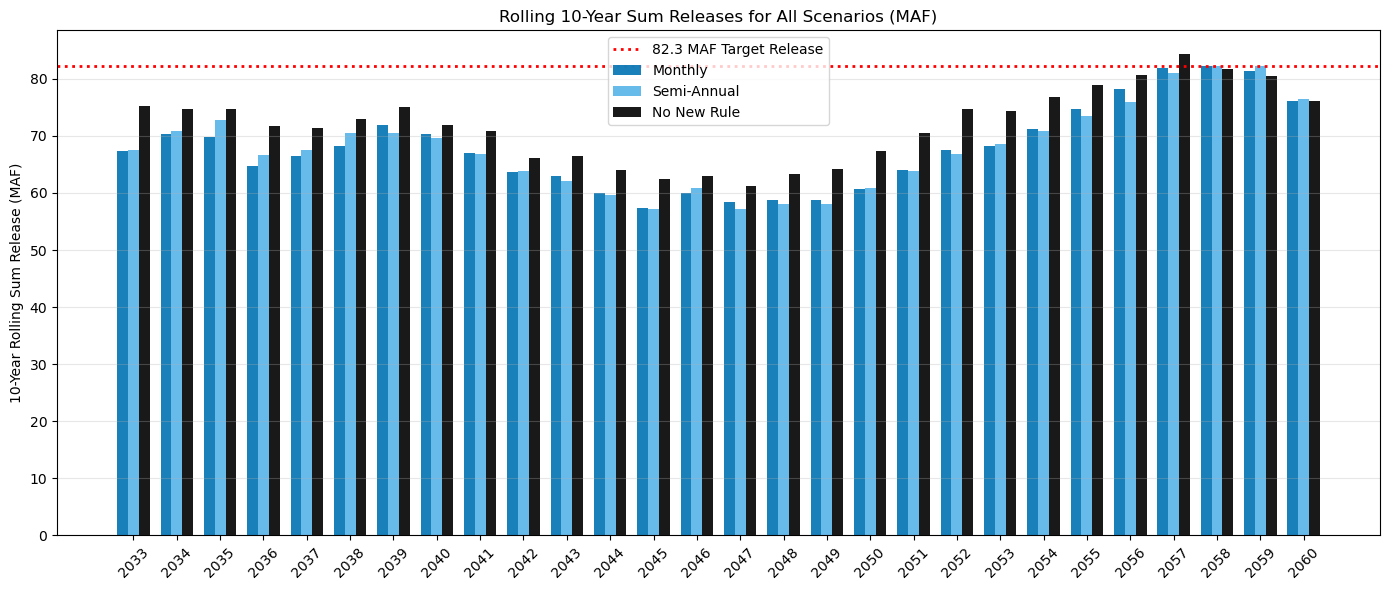

      Monthly (MAF)  Semi-Annual (MAF)  No Rule (MAF)  No Rule − Monthly (MAF)  No Rule − Semi-Annual (MAF)  Monthly - Semi-Annual
year                                                                                                                              
2033          67.32              67.48          75.19                     7.86                         7.70                  -0.16
2034          70.40              70.87          74.77                     4.37                         3.89                  -0.47
2035          69.80              72.81          74.68                     4.88                         1.87                  -3.02
2036          64.69              66.71          71.72                     7.03                         5.01                  -2.02
2037          66.51              67.61          71.34                     4.83                         3.73                  -1.10
2038          68.26              70.57          73.02                     4.77     

In [132]:
rolling10 = annual_maf.rolling(window=10).sum()
rolling10 = rolling10[rolling10.index >= 2033]

# Add difference columns
rolling10["Diff: No Rule vs Monthly"]     = rolling10["Powell.Outflow"] - rolling10["Scenario1.Outflow"]
rolling10["Diff: No Rule vs Semi-Annual"] = rolling10["Powell.Outflow"] - rolling10["Scenario2.Outflow"]
rolling10["Diff: Monthly vs Semi-Annual"] = rolling10["Scenario1.Outflow"] - rolling10["Scenario2.Outflow"]


years = rolling10.index
n_years = len(years)

bar_width = 0.25
x = np.arange(n_years)

plt.figure(figsize=(14,6))

plot_cols = ["Scenario1.Outflow", "Scenario2.Outflow", "Powell.Outflow"]
for i, col in enumerate(plot_cols):
    plt.bar(
        x + i * bar_width,
        rolling10[col],
        width=bar_width,
        label=labels[col],
        color=colors[col],
        alpha=0.9
    )

plt.axhline(82.3, color="red", linestyle=":", linewidth=2.0, label="82.3 MAF Target Release")

plt.xticks(x + bar_width, years, rotation=45)
plt.ylabel("10-Year Rolling Sum Release (MAF)")
plt.title("Rolling 10-Year Sum Releases for All Scenarios (MAF)")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Print table with differences
print_cols = {
    "Scenario1.Outflow":             "Monthly (MAF)",
    "Scenario2.Outflow":             "Semi-Annual (MAF)",
    "Powell.Outflow":                "No Rule (MAF)",
    "Diff: No Rule vs Monthly":      "No Rule − Monthly (MAF)",
    "Diff: No Rule vs Semi-Annual":  "No Rule − Semi-Annual (MAF)",
    "Diff: Monthly vs Semi-Annual":  "Monthly - Semi-Annual",
}

table = rolling10[list(print_cols.keys())].rename(columns=print_cols).round(2)
print(table.to_string())

In [134]:
print("\n--- Average Difference Over All 10-Year Windows ---")
print(table[["No Rule − Monthly (MAF)", "No Rule − Semi-Annual (MAF)","Monthly - Semi-Annual"]].mean().round(2).to_string())


--- Average Difference Over All 10-Year Windows ---
No Rule − Monthly (MAF)        4.03
No Rule − Semi-Annual (MAF)    4.04
Monthly - Semi-Annual          0.00
